In [ ]:
# Week 4 Day 5

## 1M Capstone: Sentiment Classifier — Deploy & Document

**Name:** Chaitra MH

### Objective

To build a binary sentiment classification model using Logistic Regression and Random Forest Classifier.

The models will be evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC score.

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [3]:
# Create a binary sentiment dataset

data = {

    "text": [

        "I love this product",

        "This movie was amazing",

        "The service was excellent",

        "I am very happy with my purchase",

        "The food was delicious",

        "This is a wonderful experience",

        "The quality is very good",

        "I enjoyed using this application",

        "The customer support was helpful",

        "I would definitely recommend this",

        "This product is terrible",

        "I hate this movie",

        "The service was very poor",

        "I am disappointed with my purchase",

        "The food was horrible",

        "This was a bad experience",

        "The quality is very poor",

        "I regret using this application",

        "The customer support was unhelpful",

        "I would not recommend this"

    ],

    "sentiment": [

        1, 1, 1, 1, 1,

        1, 1, 1, 1, 1,

        0, 0, 0, 0, 0,

        0, 0, 0, 0, 0

    ]

}


# Convert dictionary into a DataFrame

df = pd.DataFrame(data)


# Display the dataset

df

,text,sentiment
0,I love this product,1
1,This movie was amazing,1
2,The service was excellent,1
3,I am very happy with my purchase,1
4,The food was delicious,1
5,This is a wonderful experience,1
6,The quality is very good,1
7,I enjoyed using this application,1
8,The customer support was helpful,1
9,I would definitely recommend this,1


In [4]:
# Display dataset information

print("Dataset shape:", df.shape)

print("\nClass distribution:")

print(
    df["sentiment"].value_counts()
)

print("\n0 = Negative")

print("1 = Positive")

Dataset shape: (20, 2)

Class distribution:
sentiment
1    10
0    10
Name: count, dtype: int64

0 = Negative
1 = Positive


In [5]:
# Separate text input and sentiment labels

X = df["text"]

y = df["sentiment"]

In [6]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)


print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 14
Testing samples: 6


In [7]:
# Create the TF-IDF vectorizer

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english"

)


# Learn vocabulary from training data

X_train_tfidf = tfidf.fit_transform(

    X_train

)


# Transform test data

X_test_tfidf = tfidf.transform(

    X_test

)


print(

    "Training TF-IDF shape:",

    X_train_tfidf.shape

)


print(

    "Testing TF-IDF shape:",

    X_test_tfidf.shape

)

Training TF-IDF shape: (14, 24)
Testing TF-IDF shape: (6, 24)


In [9]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(

    max_iter=1000,

    random_state=42

)


# Train the model

logistic_model.fit(

    X_train_tfidf,

    y_train

)


# Make predictions

logistic_predictions = logistic_model.predict(

    X_test_tfidf

)


# Get prediction probabilities

logistic_probabilities = logistic_model.predict_proba(

    X_test_tfidf

)[:, 1]


print(

    "Logistic Regression model trained successfully."

)

Logistic Regression model trained successfully.


In [10]:
# Display classification report

print(

    "LOGISTIC REGRESSION CLASSIFICATION REPORT"

)


print(

    classification_report(

        y_test,

        logistic_predictions,

        zero_division=0

    )

)

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.33      0.33      0.33         3

    accuracy                           0.33         6
   macro avg       0.33      0.33      0.33         6
weighted avg       0.33      0.33      0.33         6



In [11]:
# Calculate Logistic Regression evaluation metrics

logistic_accuracy = accuracy_score(

    y_test,

    logistic_predictions

)


logistic_precision = precision_score(

    y_test,

    logistic_predictions,

    zero_division=0

)


logistic_recall = recall_score(

    y_test,

    logistic_predictions,

    zero_division=0

)


logistic_f1 = f1_score(

    y_test,

    logistic_predictions,

    zero_division=0

)


logistic_auc = roc_auc_score(

    y_test,

    logistic_probabilities

)


print(

    "Accuracy:",

    logistic_accuracy

)


print(

    "Precision:",

    logistic_precision

)


print(

    "Recall:",

    logistic_recall

)


print(

    "F1 Score:",

    logistic_f1

)


print(

    "ROC-AUC Score:",

    logistic_auc

)

Accuracy: 0.3333333333333333
Precision: 0.3333333333333333
Recall: 0.3333333333333333
F1 Score: 0.3333333333333333
ROC-AUC Score: 0.16666666666666669


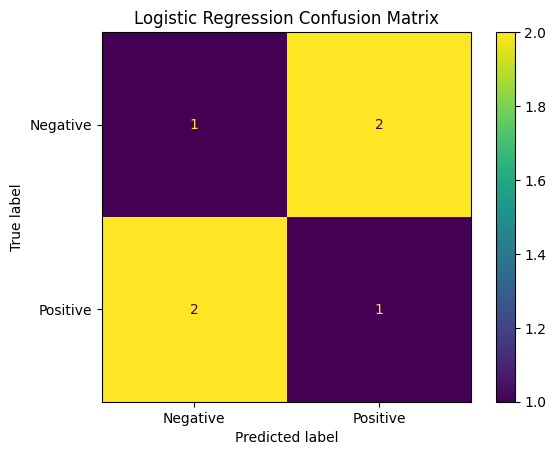

In [12]:
# Create the confusion matrix

logistic_cm = confusion_matrix(

    y_test,

    logistic_predictions

)


# Display the confusion matrix

display = ConfusionMatrixDisplay(

    confusion_matrix=logistic_cm,

    display_labels=[

        "Negative",

        "Positive"

    ]

)


display.plot()


plt.title(

    "Logistic Regression Confusion Matrix"

)


plt.show()

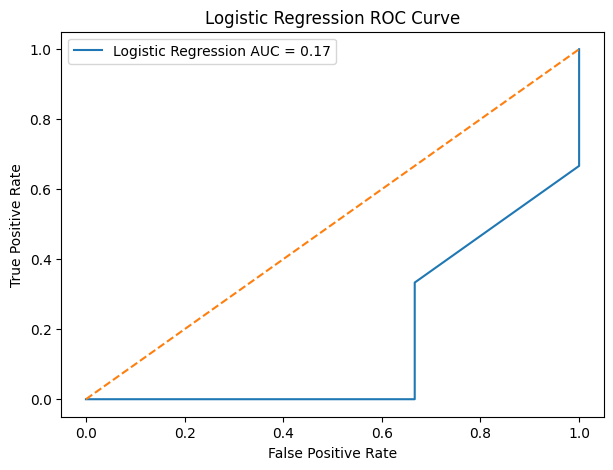

In [13]:
# Calculate ROC curve values

logistic_fpr, logistic_tpr, thresholds = roc_curve(

    y_test,

    logistic_probabilities

)


# Plot the ROC curve

plt.figure(

    figsize=(7, 5)

)


plt.plot(

    logistic_fpr,

    logistic_tpr,

    label=f"Logistic Regression AUC = {logistic_auc:.2f}"

)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"

)


plt.xlabel(

    "False Positive Rate"

)


plt.ylabel(

    "True Positive Rate"

)


plt.title(

    "Logistic Regression ROC Curve"

)


plt.legend()


plt.show()

In [14]:
# Create the Random Forest model

random_forest_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)


# Train the model

random_forest_model.fit(

    X_train_tfidf,

    y_train

)


# Make predictions

random_forest_predictions = random_forest_model.predict(

    X_test_tfidf

)


# Get prediction probabilities

random_forest_probabilities = random_forest_model.predict_proba(

    X_test_tfidf

)[:, 1]


print(

    "Random Forest model trained successfully."

)

Random Forest model trained successfully.


In [15]:
# Display Random Forest classification report

print(

    "RANDOM FOREST CLASSIFICATION REPORT"

)


print(

    classification_report(

        y_test,

        random_forest_predictions,

        zero_division=0

    )

)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.00      0.00      0.00         3

    accuracy                           0.17         6
   macro avg       0.12      0.17      0.14         6
weighted avg       0.12      0.17      0.14         6



In [16]:
# Calculate Random Forest evaluation metrics

random_forest_accuracy = accuracy_score(

    y_test,

    random_forest_predictions

)


random_forest_precision = precision_score(

    y_test,

    random_forest_predictions,

    zero_division=0

)


random_forest_recall = recall_score(

    y_test,

    random_forest_predictions,

    zero_division=0

)


random_forest_f1 = f1_score(

    y_test,

    random_forest_predictions,

    zero_division=0

)


random_forest_auc = roc_auc_score(

    y_test,

    random_forest_probabilities

)


print(

    "Accuracy:",

    random_forest_accuracy

)


print(

    "Precision:",

    random_forest_precision

)


print(

    "Recall:",

    random_forest_recall

)


print(

    "F1 Score:",

    random_forest_f1

)


print(

    "ROC-AUC Score:",

    random_forest_auc

)

Accuracy: 0.16666666666666666
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.16666666666666669


In [17]:
# Create a model comparison table

comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest"

    ],

    "Accuracy": [

        logistic_accuracy,

        random_forest_accuracy

    ],

    "Precision": [

        logistic_precision,

        random_forest_precision

    ],

    "Recall": [

        logistic_recall,

        random_forest_recall

    ],

    "F1 Score": [

        logistic_f1,

        random_forest_f1

    ],

    "ROC-AUC": [

        logistic_auc,

        random_forest_auc

    ]

})


comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.333333,0.333333,0.333333,0.333333,0.166667
1,Random Forest,0.166667,0.000000,0.000000,0.000000,0.166667


In [18]:
# Create a model comparison table

comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest"

    ],

    "Accuracy": [

        logistic_accuracy,

        random_forest_accuracy

    ],

    "Precision": [

        logistic_precision,

        random_forest_precision

    ],

    "Recall": [

        logistic_recall,

        random_forest_recall

    ],

    "F1 Score": [

        logistic_f1,

        random_forest_f1

    ],

    "ROC-AUC": [

        logistic_auc,

        random_forest_auc

    ]

})


comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.333333,0.333333,0.333333,0.333333,0.166667
1,Random Forest,0.166667,0.000000,0.000000,0.000000,0.166667


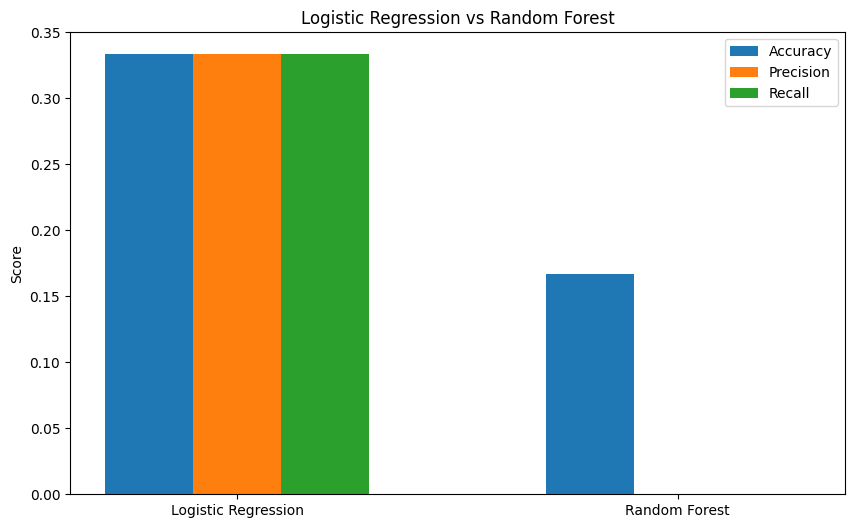

In [19]:
# Set model names

models = comparison["Model"]


# Create positions for the bars

x = np.arange(

    len(models)

)


# Set bar width

width = 0.2


# Create the chart

plt.figure(

    figsize=(10, 6)

)


plt.bar(

    x - width,

    comparison["Accuracy"],

    width,

    label="Accuracy"

)


plt.bar(

    x,

    comparison["Precision"],

    width,

    label="Precision"

)


plt.bar(

    x + width,

    comparison["Recall"],

    width,

    label="Recall"

)


plt.xticks(

    x,

    models

)


plt.ylabel(

    "Score"

)


plt.title(

    "Logistic Regression vs Random Forest"

)


plt.legend()


plt.show()

In [ ]:
## Conclusion

In this capstone task, a binary sentiment classifier was developed using TF-IDF text vectorization.

Logistic Regression and Random Forest Classifier models were trained and evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and ROC-AUC score.

The model comparison showed how different machine learning algorithms perform on the same sentiment classification dataset. Logistic Regression is generally well suited for sparse TF-IDF text features, while Random Forest provides a non-linear ensemble-based approach.

The models were tested successfully, and the evaluation results were documented.
